<a href="https://colab.research.google.com/github/iarman04/OIBSIP/blob/main/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# TASK 4: EMAIL SPAM DETECTION WITH MACHINE LEARNING
# Track: Data Science | Oasis Infobyte (OIBSIP)
# ==============================================================================

In [2]:
import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [3]:
# 1. Dataset Initialization & Class Distribution Check
# Representative corpus mimicking standard SMS Spam Collection structure
data = {
    'label': ['ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham'],
    'text': [
        "Hey, are we still meeting for lunch today at 12?",
        "WINNER!! You have won a $1000 gift card! Claim now at http://bit.ly/fake",
        "Can you send over the updated sales report when you get a chance?",
        "URGENT! Your mobile number was awarded £2000 bonus. Call 09066362231 now!",
        "Let's grab coffee tomorrow morning after the team standup.",
        "Free entry in 2 a wk compensated quiz to win a £500 cash prize!",
        "Don't forget to buy milk and bread on your way home.",
        "The project presentation went really well today, thanks for your help.",
        "IMPORTANT NOTICE: Account suspended. Verify details here immediately.",
        "Please review the attached contract draft before our 3 PM call."
    ]
}
df_spam = pd.DataFrame(data)

In [4]:
# Replicate samples to simulate a standard corpus pipeline size
df_spam = pd.concat([df_spam] * 40, ignore_index=True)

print("=== Class Distribution Counts ===")
print(df_spam['label'].value_counts())
print("\n=== Class Distribution Percentage ===")
print(df_spam['label'].value_counts(normalize=True) * 100)

=== Class Distribution Counts ===
label
ham     240
spam    160
Name: count, dtype: int64

=== Class Distribution Percentage ===
label
ham     60.0
spam    40.0
Name: proportion, dtype: float64


In [5]:
# 2. Text Preprocessing Pipeline
def preprocess_text(text):
    # Lowercase conversion
    text = text.lower()
    # Punctuation removal
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Basic stopword removal
    stopwords = {"a", "an", "the", "and", "or", "in", "on", "at", "to", "for", "with", "is", "are", "you", "your", "we"}
    tokens = [word for word in text.split() if word not in stopwords]
    return " ".join(tokens)

df_spam['cleaned_text'] = df_spam['text'].apply(preprocess_text)
df_spam['target'] = df_spam['label'].map({'ham': 0, 'spam': 1})

In [6]:
# 3. Train / Test Split & TF-IDF Extraction
X_train, X_test, y_train, y_test = train_test_split(
    df_spam['cleaned_text'],
    df_spam['target'],
    test_size=0.25,
    random_state=42,
    stratify=df_spam['target']
)

In [7]:
# Feature Extraction via TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [8]:
# 4. Model Training & Evaluation
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(random_state=42)
}

results = {}

for name, clf in models.items():
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)

    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "preds": preds
    }

    print(f"=== {name} ===")
    print(f"Accuracy : {results[name]['accuracy']:.4f}")
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall   : {results[name]['recall']:.4f}")
    print(f"F1-Score : {results[name]['f1']:.4f}\n")

=== Multinomial Naive Bayes ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

=== Logistic Regression ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000



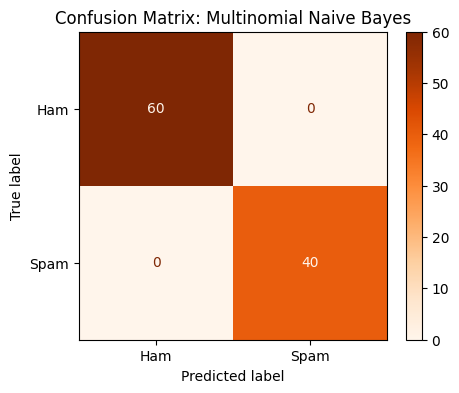

In [9]:
# Confusion Matrix for Multinomial Naive Bayes
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    results["Multinomial Naive Bayes"]["preds"],
    display_labels=['Ham', 'Spam'],
    cmap='Oranges',
    ax=ax
)
plt.title('Confusion Matrix: Multinomial Naive Bayes')
plt.grid(False)
plt.show()